<a href="https://colab.research.google.com/github/deboraluz/deboraluz/blob/main/Profissao_Cientista_de_Dados_M15_Pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [29]:
df = pd.read_csv('M15_TAREFA.csv')

df.head()

,customerID,gender,senior_citizen,married,Dependents,time_as_customer,internet_service,security_service,technical_support,StreamingTV,contract_type,PaymentMethod,monthly_payment,total_paid,Churn
0,7590-VHVEG,Female,0,Yes,No,1,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,DSL,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
4,9237-HQITU,Male,0,No,No,2,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,151.65,Yes


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [30]:
#A
df.describe()

,senior_citizen,time_as_customer,monthly_payment,total_paid
count,2495.000000,2495.000000,2495.000000,2495.000000
mean,0.161122,32.354309,66.356894,2292.625812
std,0.367717,24.634007,28.013627,2266.888527
min,0.000000,0.000000,18.400000,18.800000
25%,0.000000,8.000000,45.550000,402.175000
50%,0.000000,29.000000,71.450000,1404.650000
75%,0.000000,56.000000,87.375000,3874.750000
max,1.000000,72.000000,118.650000,8564.750000


A variável time_as_customer apresenta média de aproximadamente 32 meses e mediana de 29 meses, indicando uma distribuição relativamente próxima entre média e mediana. A variável monthly_payment possui média de 66,36 e mediana de 71,45, indicando uma possível concentração de clientes em valores mais altos e uma distribuição assimétrica. Já total_paid apresenta uma diferença maior entre média 2.292,63 e mediana 1.404,65, indicando uma distribuição mais assimétrica, com clientes que possuem valores totais pagos significativamente maiores.

In [31]:
#B
variaveis_numericas = [
    'time_as_customer',
    'monthly_payment',
    'total_paid']

for coluna in variaveis_numericas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)]

    print(f'{coluna}: {len(outliers)} outliers')
    print(f'Limite inferior: {limite_inferior:.2f}')
    print(f'Limite superior: {limite_superior:.2f}')
    print()

time_as_customer: 0 outliers
Limite inferior: -64.00
Limite superior: 128.00

monthly_payment: 0 outliers
Limite inferior: -17.19
Limite superior: 150.11

total_paid: 0 outliers
Limite inferior: -4806.69
Limite superior: 9083.61



A base não apresenta outliers segundo o critério de 1,5 x IQR nas variáveis numéricas analisadas. Apesar de parecer que a variável total_paid tenha uma distribuição assimétrica, isso não significa que existam outliers.

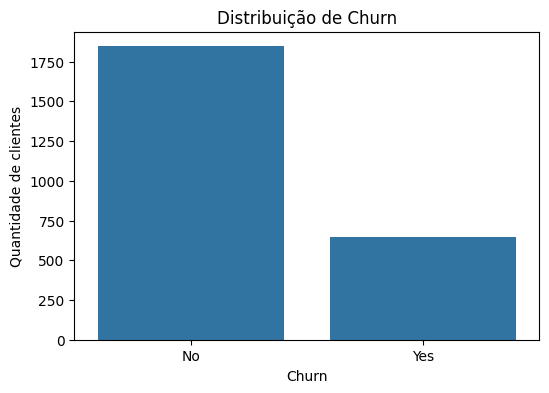

In [32]:
#C 1
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Churn')

plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de clientes')

plt.show()

A variável Churn apresenta uma distribuição desequilibrada, com aproximadamente 74% dos clientes permanecendo na empresa e 26% apresentando churn. Portanto, a maior parte da base é composta por clientes que não cancelaram o serviço.

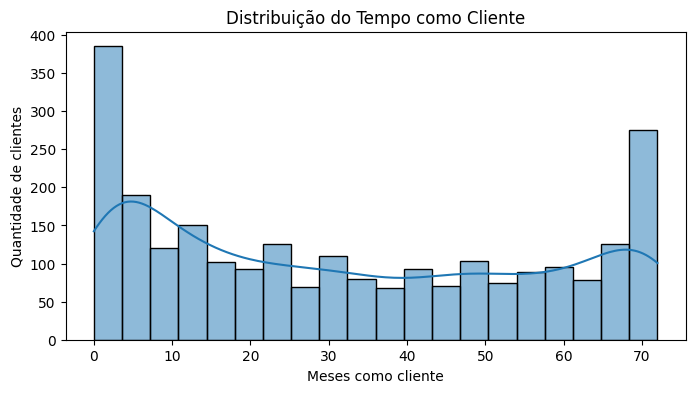

In [33]:
#C 2
plt.figure(figsize=(8,4))

sns.histplot(data=df, x='time_as_customer', bins=20, kde=True)

plt.title('Distribuição do Tempo como Cliente')
plt.xlabel('Meses como cliente')
plt.ylabel('Quantidade de clientes')

plt.show()

O tempo como cliente varia de 0 a 72 meses, com média de aproximadamente 32 meses. A distribuição apresenta clientes em diferentes estágios do relacionamento com a empresa, permitindo posteriormente investigar se clientes mais recentes apresentam maior tendência ao churn.

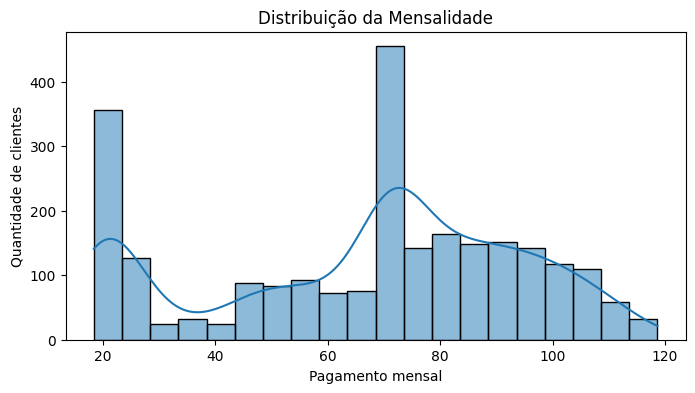

In [34]:
#C 3
plt.figure(figsize=(8,4))

sns.histplot(data=df, x='monthly_payment', bins=20, kde=True)

plt.title('Distribuição da Mensalidade')
plt.xlabel('Pagamento mensal')
plt.ylabel('Quantidade de clientes')

plt.show()

O valor da mensalidade varia de 18,40 a 118,65. A média é de 66,36, enquanto a mediana é de 71,45. A diferença entre esses valores indica uma distribuição assimétrica, que pode estar relacionada aos diferentes serviços contratados pelos clientes.

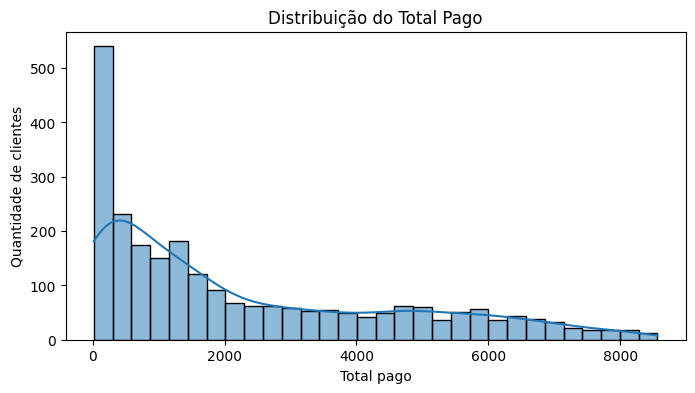

In [35]:
#C 4
plt.figure(figsize=(8,4))

sns.histplot(data=df, x='total_paid', bins=30, kde=True)

plt.title('Distribuição do Total Pago')
plt.xlabel('Total pago')
plt.ylabel('Quantidade de clientes')

plt.show()

O total pago apresenta uma distribuição bastante assimétrica. A mediana é de aproximadamente 1.404,65, enquanto a média é de 2.292,63. Isso indica que existem clientes com valores totais pagos bastante superiores à maior parte da base, o que pode estar relacionado principalmente ao tempo de permanência como cliente.

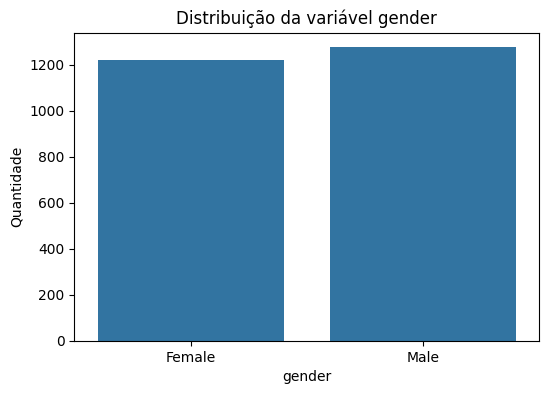

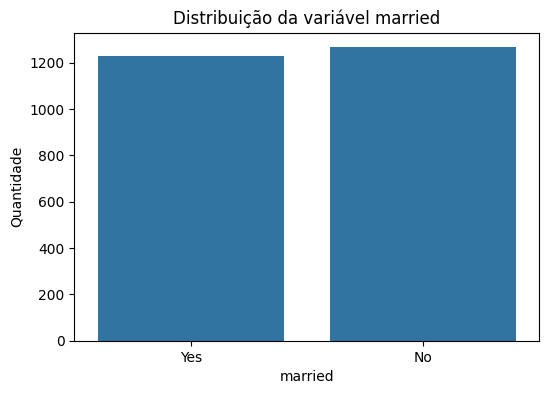

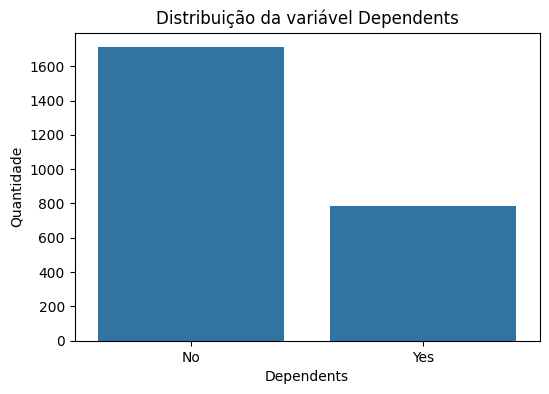

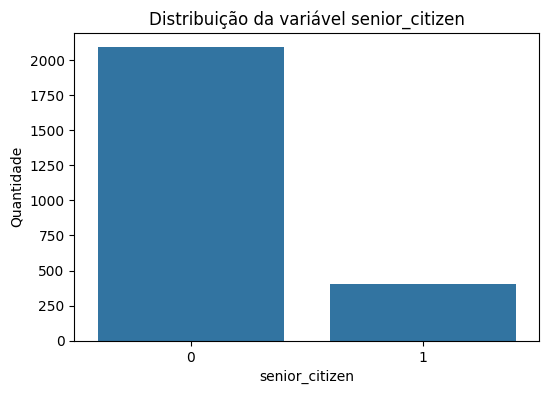

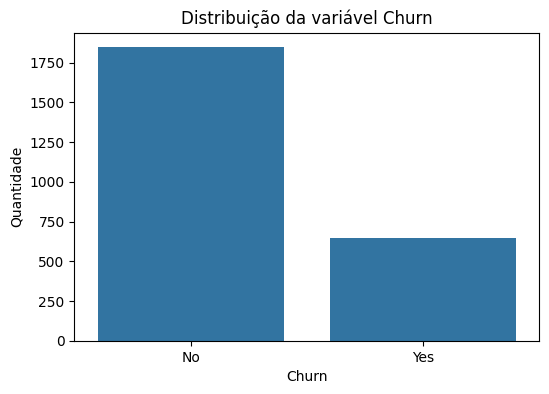

In [36]:
#D
variaveis_booleanas = [
    'gender',
    'married',
    'Dependents',
    'senior_citizen',
    'Churn'
]

for coluna in variaveis_booleanas:
    plt.figure(figsize=(6,4))

    sns.countplot(data=df, x=coluna)

    plt.title(f'Distribuição da variável {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Quantidade')

    plt.show()

As variáveis gender e married apresentam distribuições bastante equilibradas. Já Dependents apresenta maior concentração de clientes sem dependentes, enquanto senior_citizen possui uma concentração ainda maior de clientes que não são idosos. A variável alvo Churn também é desequilibrada, pois apenas 26% dos clientes apresentam churn. Esse desequilíbrio deverá ser considerado posteriormente em uma eventual etapa de modelagem.

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


In [37]:
#Verificação dos outliers pelo método do IQR
for coluna in ['time_as_customer', 'monthly_payment', 'total_paid']:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)]

    print(f'{coluna}: {len(outliers)} outliers')

time_as_customer: 0 outliers
monthly_payment: 0 outliers
total_paid: 0 outliers


Após a análise das variáveis numéricas pelo método do intervalo interquartil (IQR), não foram identificados outliers nas variáveis time_as_customer, monthly_payment e total_paid. Dessa forma, optei por manter todos os registros da base. Apesar de total_paid apresentar uma distribuição assimétrica, os valores extremos encontrados ainda estão dentro dos limites definidos pelo método utilizado e não há evidência suficiente para considerá-los erros ou removê-los.

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

1. Clientes com contratos mais curtos têm mais churn?
2. O serviço de internet está relacionado ao churn?
3. O método de pagamento está relacionado ao churn?
4. Clientes que pagam mensalidades maiores apresentam mais churn?
5. Clientes mais antigos apresentam menos churn?
6. Clientes idosos apresentam maior churn?

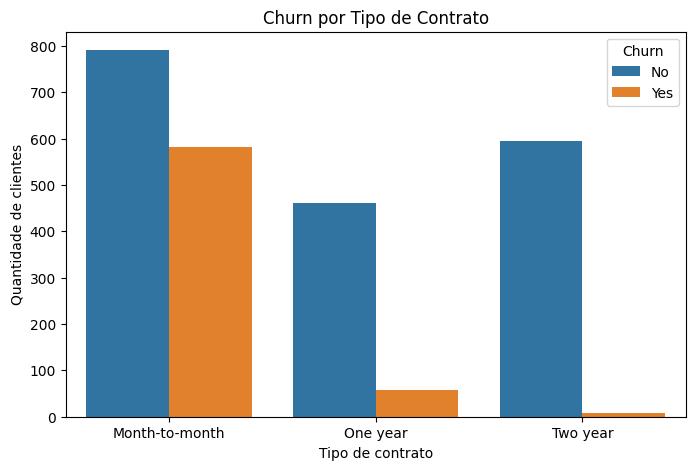

In [38]:
#A 1
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='contract_type',
    hue='Churn'
)

plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Quantidade de clientes')

plt.show()

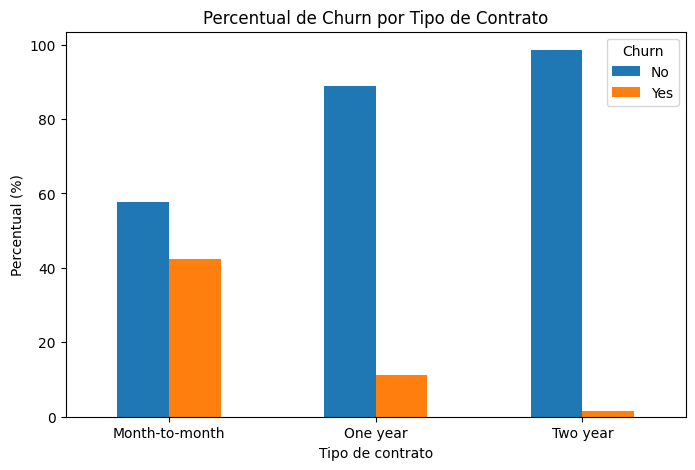

In [39]:
#em %
contrato_churn = pd.crosstab(
    df['contract_type'],
    df['Churn'],
    normalize='index') * 100

contrato_churn.plot(
    kind='bar',
    figsize=(8,5))

plt.title('Percentual de Churn por Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

plt.show()

O tipo de contrato apresenta uma forte relação com o churn. Clientes com contrato mensal apresentam uma taxa de churn de aproximadamente 42,4%, enquanto clientes com contratos de um ano apresentam 11,2% e contratos de dois anos apenas 1,5%. Isso indica que clientes com contratos de maior duração tendem a permanecer mais tempo na empresa.

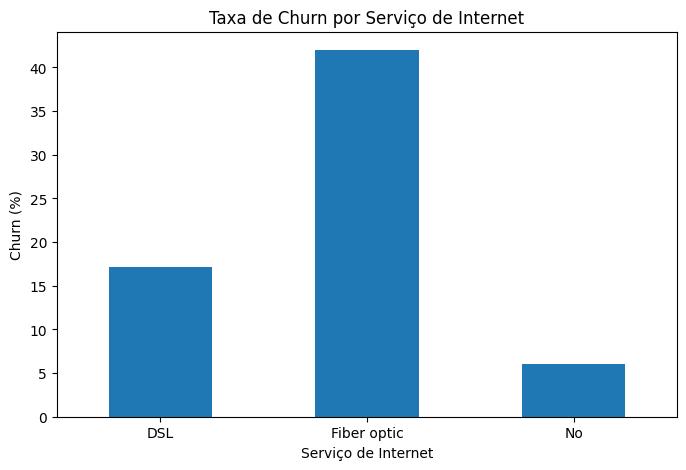

In [40]:
#A 2
internet_churn = pd.crosstab(
    df['internet_service'],
    df['Churn'],
    normalize='index') * 100

internet_churn['Yes'].plot(
    kind='bar',
    figsize=(8,5))

plt.title('Taxa de Churn por Serviço de Internet')
plt.xlabel('Serviço de Internet')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)

plt.show()


In [41]:
internet_churn = pd.crosstab(
    df['internet_service'],
    df['Churn'],
    normalize='index') * 100

print(internet_churn.round(2))

Churn                No    Yes
internet_service              
DSL               82.80  17.20
Fiber optic       58.01  41.99
No                93.94   6.06


O tipo de serviço de internet apresenta uma relação relevante com o churn. Clientes que utilizam fibra óptica apresentam taxa de churn de aproximadamente 42%, significativamente superior à observada entre clientes DSL (17,2%) e clientes sem serviço de internet (6,1%). A variável merece atenção na construção do modelo preditivo.

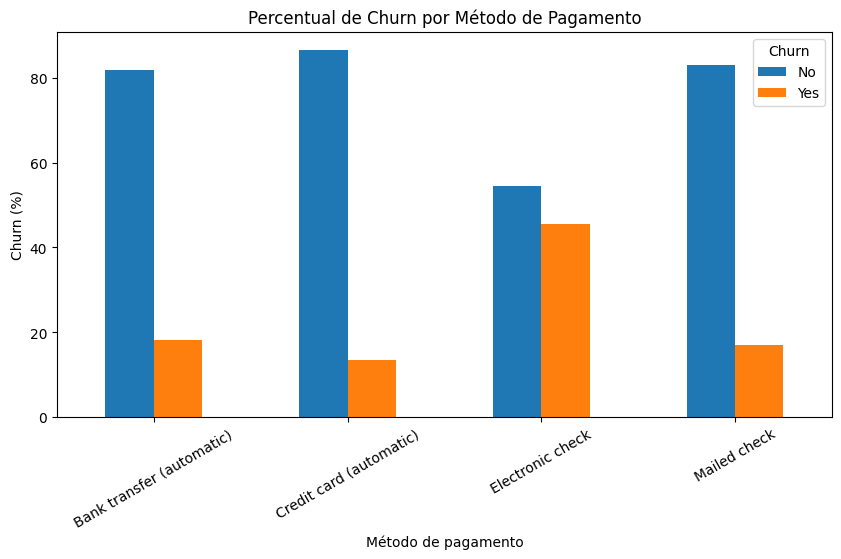

In [42]:
#A 3
pagamento_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index') * 100

pagamento_churn.plot(
    kind='bar',
    figsize=(10,5))

plt.title('Percentual de Churn por Método de Pagamento')
plt.xlabel('Método de pagamento')
plt.ylabel('Churn (%)')
plt.xticks(rotation=30)

plt.show()

O método de pagamento também apresenta uma diferença significativa na taxa de churn. Clientes que utilizam pagamento por cheque eletrônico apresentam churn de aproximadamente 45,6%, enquanto os demais métodos apresentam taxas entre 13,5% e 18,1%. Essa diferença indica que o método de pagamento pode ser uma variável importante para explicar o comportamento de cancelamento.

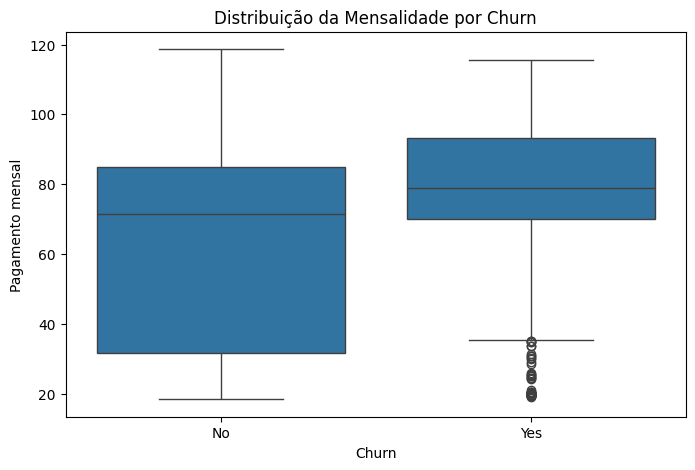

In [43]:
#A 4
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='monthly_payment')

plt.title('Distribuição da Mensalidade por Churn')
plt.xlabel('Churn')
plt.ylabel('Pagamento mensal')

plt.show()

O boxplot indica que os clientes que realizaram churn tendem a apresentar mensalidades maiores. A média da mensalidade entre os clientes que permaneceram é de aproximadamente 62,99, enquanto entre os clientes que realizaram churn é de aproximadamente 75,94. Isso sugere uma possível relação entre valores mensais mais elevados e maior probabilidade de cancelamento.

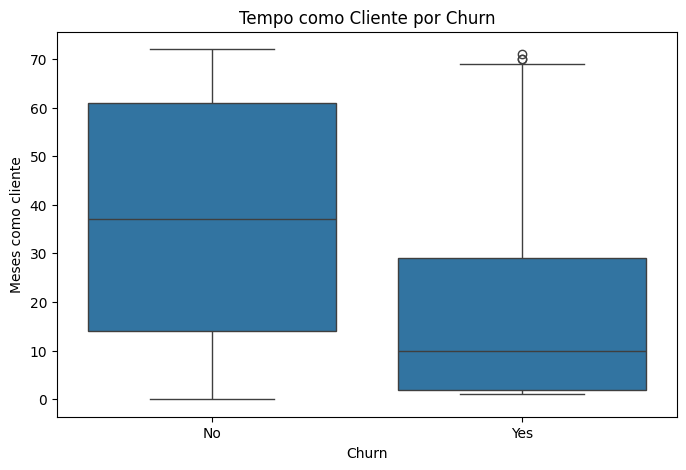

In [44]:
#A 5
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='time_as_customer')

plt.title('Tempo como Cliente por Churn')
plt.xlabel('Churn')
plt.ylabel('Meses como cliente')

plt.show()

Existe uma diferença significativa no tempo de permanência entre os grupos. Clientes que não realizaram churn possuem média de aproximadamente 37,4 meses como clientes, enquanto aqueles que realizaram churn possuem média de aproximadamente 18 meses. Isso indica que clientes mais recentes parecem apresentar maior propensão ao cancelamento.

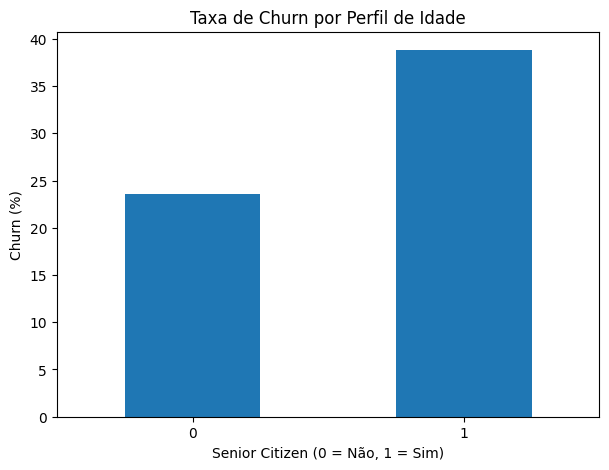

In [45]:
#A 6
senior_churn = pd.crosstab(
    df['senior_citizen'],
    df['Churn'],
    normalize='index') * 100

senior_churn['Yes'].plot(
    kind='bar',
    figsize=(7,5))

plt.title('Taxa de Churn por Perfil de Idade')
plt.xlabel('Senior Citizen (0 = Não, 1 = Sim)')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)

plt.show()

Clientes classificados como senior_citizen apresentam uma taxa de churn de aproximadamente 38%, enquanto os demais apresentam 23%. Apesar de representarem uma parcela menor da base, os clientes idosos apresentam uma taxa de cancelamento consideravelmente maior.

5.
Com base na análise bivariada, as variáveis que aparentam apresentar maior relação com o Churn são contract_type, PaymentMethod, internet_service, time_as_customer e monthly_payment. O tipo de contrato apresenta uma diferença especialmente expressiva: clientes com contratos mensais possuem taxa de churn muito superior àqueles com contratos anuais ou bienais. O método de pagamento e o serviço de internet também apresentam diferenças relevantes nas taxas de cancelamento. Além disso, clientes que realizaram churn apresentam, em média, menor tempo como clientes e maior mensalidade.

Essas relações não significam necessariamente causalidade, mas indicam quais variáveis podem ser importantes para uma futura etapa de modelagem preditiva.